# 0.0 Baseline

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn import model_selection as ms
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from scipy.stats import gaussian_kde



In [3]:
df_raw = pd.read_csv("/home/alvaro/Documentos/alvaro/comunidadeds/projetos/metodologiacrisp/dataset/HR-Employee-Attrition-balanced - HR-Employee-Attrition-balanced.csv")

In [4]:
# Research - Pesquisa de Mercado (SHRM)
# Entry-level (Cargos Operacionais): 40% do salário anual
# Professional (Especialistas): 100% do salário anual
# Manager (Gestores e Executivos): 200% do salário anual

baseline_df = df_raw.copy()

baseline_df['Annual_Salary'] = baseline_df['MonthlyIncome'] * 12
baseline_df['Replacement_Multiplier'] = baseline_df['JobLevel'].apply( lambda x: 0.40 if x <= 2 else 1.00 if x == 3 else 2.00 )
baseline_df['Replacement_Cost'] = baseline_df['Annual_Salary'] * baseline_df['Replacement_Multiplier']

# Isolando apenas as perdas (pessoas que pediram demissão)
leaving_df = baseline_df[baseline_df['Attrition'] == 'Yes']

# Metrics: 
total_employees = len(baseline_df)
employees_leaving = len(leaving_df)
attrition_rate = (employees_leaving / total_employees) * 100
avg_replacement_cost = leaving_df['Replacement_Cost'].mean()
total_annual_cost = leaving_df['Replacement_Cost'].sum()

print("="*60)
print("SITUAÇÃO ATUAL (BASELINE SEM MACHINE LEARNING)")
print("="*60)
print(f"Total de Funcionários: {total_employees}")
print(f"Funcionários que saem/ano (Rotatividade): {employees_leaving}")
print(f"Taxa de Rotatividade Anual: {attrition_rate:.2f}%")

print("-"*60)
print(f"Custo médio de substituição/pessoa: ${avg_replacement_cost:,.2f}")
print(f"Custo total anual de rotatividade: ${total_annual_cost:,.2f}")
print("="*60)


SITUAÇÃO ATUAL (BASELINE SEM MACHINE LEARNING)
Total de Funcionários: 1761
Funcionários que saem/ano (Rotatividade): 528
Taxa de Rotatividade Anual: 29.98%
------------------------------------------------------------
Custo médio de substituição/pessoa: $46,195.30
Custo total anual de rotatividade: $24,391,116.00


In [5]:
def simular_cenario_roi(recall, precision, taxa_retencao):

    # Constantes do Report
    CUSTO_MANUTENCAO_ANUAL = 20000
    CUSTO_INTERVENCAO = 5000

    # 1. Pessoas que a Máquina Aponta (Recall)
    verdadeiros_positivos = int(employees_leaving * recall)

    # 2. Pessoas Retidas de Fato pelo RH
    funcionarios_retidos = int(verdadeiros_positivos * taxa_retencao)

    # 3. Benefício Bruto (Pessoas salvas x O quanto a empresa gastaria pra demiti-las)
    economia_bruta = funcionarios_retidos * avg_replacement_cost
    
    # 5. Custos do Processo (Precisamos pagar pela manutenção de TI e pelas reuniões do RH)
    # Quantos alarmes o modelo gerou no total para conseguirmos os Verdadeiros Positivos?
    # Se a precisão é 70%, o volume total alardado é Verdadeiros Positivos / 0.70
    total_intencoes_rh = verdadeiros_positivos / precision if precision > 0 else 0
    custo_intervencoes = total_intencoes_rh * CUSTO_INTERVENCAO
    
    custos_anuais_totais = CUSTO_MANUTENCAO_ANUAL + custo_intervencoes
    
    # 6. Balanço Final
    economia_liquida = economia_bruta - custos_anuais_totais
    roi_anual = (economia_liquida / custos_anuais_totais) * 100 if custos_anuais_totais > 0 else 0
    
    return {
        "Cenário": "Simulado",
        "Precision": f"{precision*100:.0f}%",
        "Recall": f"{recall*100:.0f}%",
        "Retenção": f"{taxa_retencao*100:.0f}%",
        "Func. Retidos": funcionarios_retidos,
        "Economia Líquida (Anual)": f"${economia_liquida:,.0f}",
        "ROI Anual (%)": f"{roi_anual:.0f}%"
    }

# Criando tabela interativa com cenários conservador, moderado e otimista
tabela_analise = [
    simular_cenario_roi(precision = 0.60, recall=0.50, taxa_retencao=0.20),
    simular_cenario_roi(precision = 0.70, recall=0.60, taxa_retencao=0.30),
    simular_cenario_roi(precision = 0.80, recall=0.70, taxa_retencao=0.40),
]

df_potencial_roi = pd.DataFrame(tabela_analise)

# Renomear índices para identificar os cenários
df_potencial_roi['Cenário'] = ['Conservador', 'Moderado', 'Otimista']

display(df_potencial_roi)

,Cenário,Precision,Recall,Retenção,Func. Retidos,Economia Líquida (Anual),ROI Anual (%)
0,Conservador,60%,50%,20%,52,"$182,155",8%
1,Moderado,70%,60%,30%,94,"$2,065,215",91%
2,Otimista,80%,70%,40%,147,"$4,464,458",192%


In [6]:
baseline_df.head().T

,0,1,2,3,4
Age,58,27,50,39,32
Attrition,Yes,Yes,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Non-Travel,Travel_Rarely
DailyRate,601,1341,407,439,601
Department,Research & Development,Human Resources,Sales,Research & Development,Sales
DistanceFromHome,7,21,28,9,7
Education,4,2,3,3,5
EducationField,Medical,Human Resources,Marketing,Life Sciences,Marketing
EmployeeCount,1,1,1,1,1
EmployeeNumber,1360,1950,2049,1132,1446


## 1.0. Data Quality

In [7]:
df01 = df_raw.copy()

In [8]:
print(f'Number of rows: {df01.shape[0]} and Columns: {df01.shape[1]}')

Number of rows: 1761 and Columns: 35


### 1.1 Split Train-Test dataset

In [9]:
df01.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,58,Yes,Travel_Rarely,601,Research & Development,7,4,Medical,1,1360,...,4,80,0,31,0,2,10,9,5,9
1,27,Yes,Travel_Frequently,1341,Human Resources,21,2,Human Resources,1,1950,...,1,80,0,0,2,3,0,0,0,0
2,50,Yes,Travel_Rarely,407,Sales,28,3,Marketing,1,2049,...,2,80,1,19,3,2,2,2,1,0
3,39,No,Non-Travel,439,Research & Development,9,3,Life Sciences,1,1132,...,3,80,0,9,2,2,5,4,0,3
4,32,No,Travel_Rarely,601,Sales,7,5,Marketing,1,1446,...,3,80,1,7,3,2,4,3,0,3


### Data Split

In [10]:
X = df_raw.drop(columns = 'Attrition')
y = df_raw['Attrition']

df_train, df_test, y_train, y_test = ms.train_test_split(X,y, stratify=y)

In [11]:
df01 = pd.concat([X,y], axis=1)
df01.shape

(1761, 35)

In [12]:
df01.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,58,Travel_Rarely,601,Research & Development,7,4,Medical,1,1360,3,...,80,0,31,0,2,10,9,5,9,Yes
1,27,Travel_Frequently,1341,Human Resources,21,2,Human Resources,1,1950,0,...,80,0,0,2,3,0,0,0,0,Yes
2,50,Travel_Rarely,407,Sales,28,3,Marketing,1,2049,3,...,80,1,19,3,2,2,2,1,0,Yes
3,39,Non-Travel,439,Research & Development,9,3,Life Sciences,1,1132,3,...,80,0,9,2,2,5,4,0,3,No
4,32,Travel_Rarely,601,Sales,7,5,Marketing,1,1446,4,...,80,1,7,3,2,4,3,0,3,No


In [13]:
df_missing = df01.isna().sum()/df01.shape[0]
df_missing

Age                         0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtCompany              0.0
YearsInC

In [14]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1761 non-null   int64
 1   BusinessTravel            1761 non-null   str  
 2   DailyRate                 1761 non-null   int64
 3   Department                1761 non-null   str  
 4   DistanceFromHome          1761 non-null   int64
 5   Education                 1761 non-null   int64
 6   EducationField            1761 non-null   str  
 7   EmployeeCount             1761 non-null   int64
 8   EmployeeNumber            1761 non-null   int64
 9   EnvironmentSatisfaction   1761 non-null   int64
 10  Gender                    1761 non-null   str  
 11  HourlyRate                1761 non-null   int64
 12  JobInvolvement            1761 non-null   int64
 13  JobLevel                  1761 non-null   int64
 14  JobRole                   1761 non-null   str  
 15

# 1.0. Descriptive Analysis

In [15]:
num_attributes = df01.select_dtypes(include=['int64', 'float64'])
cat_attributes = df01.select_dtypes(include=['object'])

/tmp/ipykernel_175238/1807736368.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attributes = df01.select_dtypes(include=['object'])


In [16]:
# Central tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

#Dispersion - min, max, intervalo, std, skew, kurtosis
dt1 = pd.DataFrame(num_attributes.apply(np.std)).T
dt2 = pd.DataFrame(num_attributes.apply(np.min)).T
dt3 = pd.DataFrame(num_attributes.apply(np.max)).T
dt4 = pd.DataFrame(num_attributes.apply(lambda x: np.max(x) - np.min(x))).T 
dt5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
dt6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

m = pd.concat([ct1, ct2, dt1, dt2, dt3, dt4, dt5, dt6]).T
m.columns = ['mean', 'median', 'std', 'min', 'max', 'interval', 'skew', 'kurtosis']
m.style.background_gradient(cmap='coolwarm', axis=0).format("{:.3f}")

,mean,median,std,min,max,interval,skew,kurtosis
Age,36.369,35.000,9.373,17.000,60.000,43.000,0.419,-0.423
DailyRate,793.486,775.000,403.012,97.000,1499.000,1402.000,0.047,-1.208
DistanceFromHome,9.373,7.000,8.298,0.000,29.000,29.000,0.875,-0.445
Education,2.820,3.000,1.067,0.000,5.000,5.000,-0.294,-0.454
EmployeeCount,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000
EmployeeNumber,1030.099,1030.000,600.608,0.000,2068.000,2068.000,0.002,-1.214
EnvironmentSatisfaction,2.589,3.000,1.163,0.000,4.000,4.000,-0.335,-1.044
HourlyRate,65.768,66.000,20.235,30.000,100.000,70.000,-0.014,-1.177
JobInvolvement,2.600,3.000,0.803,0.000,4.000,4.000,-0.673,0.550
JobLevel,1.932,2.000,1.157,0.000,5.000,5.000,0.843,0.392


In [17]:
#EmployeeCount, EmployeeNumber, StandardHours

# 2.0. Feature Engineering

In [18]:
df02 = df01.copy()

### Mapa mental de Hipóteses

Influência e Atributos

- Cargo
    1. Nível
    2. Salário Mensal
    3. Treinamentos
    4. Valor-hora
    5. Hora-extra
- Funcionário
    1. Número de empresas anteriores
    2. Gênero
    3. Experiência Total
    4. Idade
    5. Educação 
    6. Estado Civil
- Empresa
    1. Stock Options
    2. Aumento salarial
    3. Avaliação de desempenho
    4. Satisfação do Ambiente
    5. Satisfação do Trabalho
    6. Departamento
- Qualidade de vida
    1. Distância de casa
    2. Equilíbrio entre vida e trabalho
    3. Viagens de negócio
- Gestão
    1. Anos sob gestão
    2. Promoção
    3. Anos no Cargo Atual
    4. Satisfação no Cargo
    5. Envolvimento no Trabalho

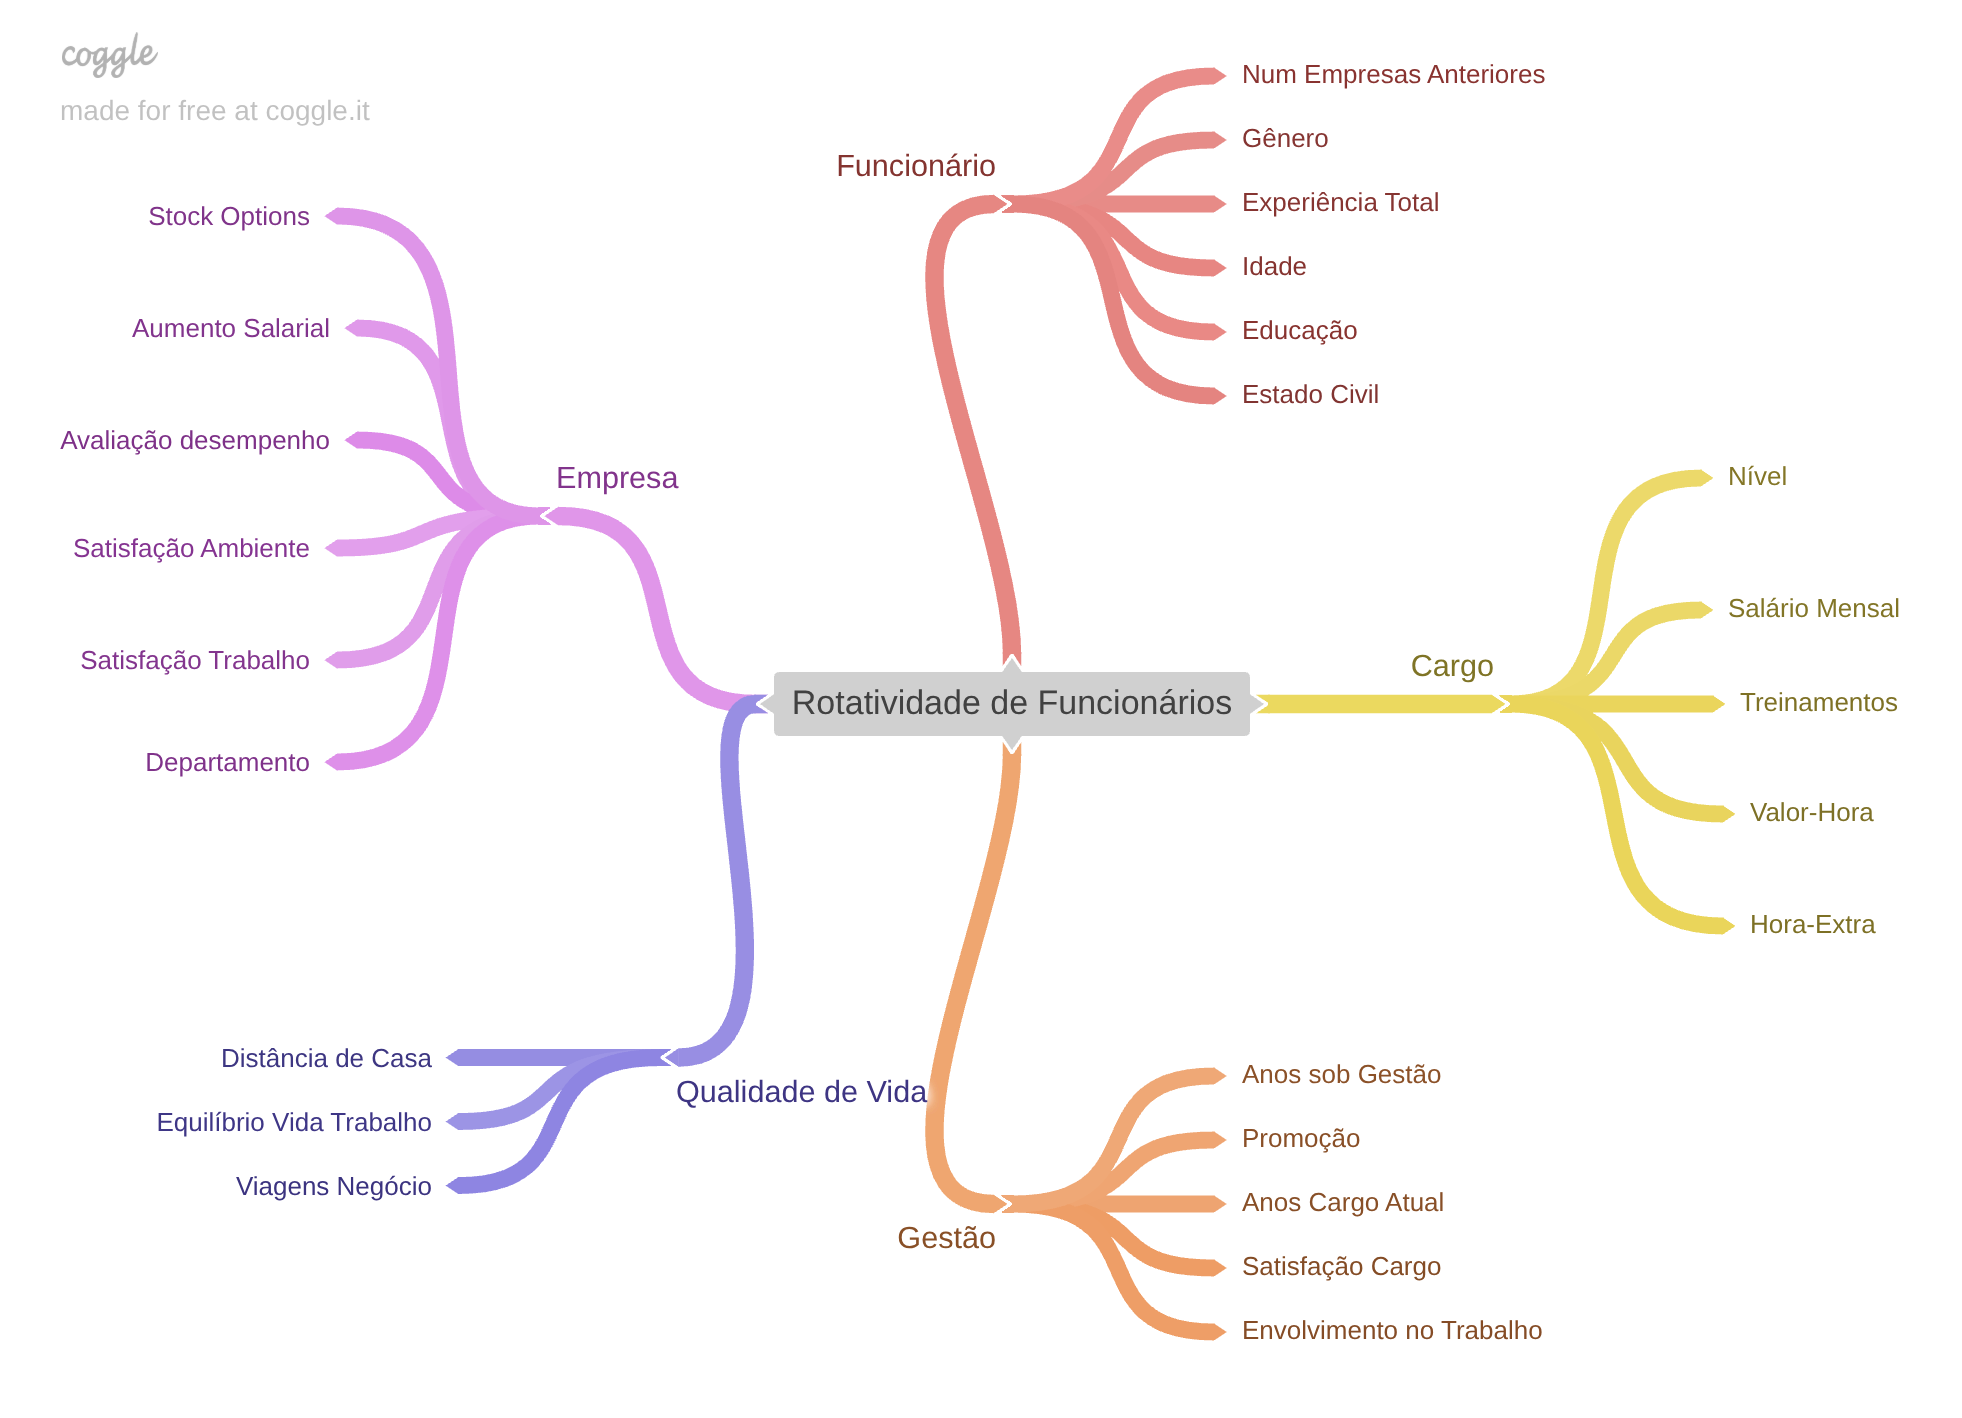

In [19]:
# Construção do mapa mental de hipóteses:
# Fenômeno: Qual fenômeno estou modelando?
# Agentes: Quem são os agentes que atuam sobre o fenômeno de interesse?
# Atributos dos agentes: que descrevem os agentes
Image('img/Rotatividade_de_Funcionarios.png')

## Criação das Hipóteses

### Dimensão: Funcionário

**H1:** Funcionários mais jovens (menores de 25 anos) tem uma taxa de rotatividade **maior** do que funcionários mais velhos.

**H2:** Funcionários solteiros tem uma taxa de rotatividade **maior** do que funcionários casados ou divorciados.

**H3:** Funcionários que já trabalharam em mais de 5 empresas anteriores tem um rotatividade maior.

### Dimensão: Cargo

**H4:** Funcionários que realizam **Horas Extras (OverTime)** tem uma taxa de rotatividade **maior**.

**H5:** Funcionários com **salários menores** (MonthlyIncome abaixo da mediana) tem um rotatividade **maior**.

**H6:** Funcionários em cargos de nível de entrada (JobLevel 1) saem **mais** do que os de níveis seniores.

### Dimensão: Empresa

**H7:** Funcionários com **baixa Satisfação com o Trabalho (JobSatisfaction 1-2)** tem maior rotatividade.

**H8:** Funcionários que não recebem opções de ações (**StockOptionLevel 0**) tem maior rotatividade.

**H9:** Funcionários em departamentos de **Vendas (Sales)** tem um rotatividade **maior** que em P&D (R&D).

### Dimensão: Gestão

**H10:** Funcionários com **pouco tempo sob o mesmo gestor** (menos de 2 anos) tem **maior** rotatividade.

**H11:** Funcionários que não são promovidos há mais de 3 anos (**YearsSinceLastPromotion**) tem **maior** probabilidade de sair.

**H12:** Funcionários com **baixo envolvimento (JobInvolvement 1-2)** tem **maior** rotatividade.

### Dimensão: Qualidade de Vida

**H13:** Funcionários que moram **mais longe do trabalho** (DistanceFromHome > 15km) tem **maior** rotatividade.

**H14:** Funcionários que viajam frequentemente (**BusinessTravel: Travel_Frequently**) tem uma taxa de rotatividade **maior**.

**H15:** Funcionários com **baixo equilíbrio de vida-trabalho (WorkLifeBalance 1-2)** deveriam sair **mais**.

## 2.1. Feature Creation

In [20]:
df02.T

,0,1,2,3,4,5,6,7,8,9,...,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760
Age,58,27,50,39,32,29,33,30,42,32,...,33,35,49,24,33,35,41,22,29,50
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Non-Travel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,...,Non-Travel,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Rarely
DailyRate,601,1341,407,439,601,337,501,1441,557,825,...,750,1208,1495,1438,589,750,447,1256,1378,264
Department,Research & Development,Human Resources,Sales,Research & Development,Sales,Research & Development,Research & Development,Research & Development,Research & Development,Research & Development,...,Sales,Sales,Research & Development,Sales,Research & Development,Research & Development,Research & Development,Research & Development,Research & Development,Sales
DistanceFromHome,7,21,28,9,7,14,15,0,18,29,...,22,4,5,0,28,28,5,3,13,9
Education,4,2,3,3,5,1,2,5,4,4,...,2,2,4,0,4,3,3,4,2,3
EducationField,Medical,Human Resources,Marketing,Life Sciences,Marketing,Other,Medical,Life Sciences,Life Sciences,Medical,...,Marketing,Technical Degree,Technical Degree,Technical Degree,Life Sciences,Life Sciences,Life Sciences,Life Sciences,Other,Marketing
EmployeeCount,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
EmployeeNumber,1360,1950,2049,1132,1446,1421,2009,1442,1998,1089,...,160,1103,1473,542,1549,1596,1814,1203,2053,1591
EnvironmentSatisfaction,3,0,3,3,4,3,2,3,4,1,...,3,3,1,0,2,2,2,3,4,3


In [21]:
# 1. Estabilidade e Fidelidade
df02['career_stability'] = df02['TotalWorkingYears'] / df02['NumCompaniesWorked']
df02['loyalty_ratio'] = df02['YearsAtCompany'] / df02['TotalWorkingYears']

# 2. Renda Relativa (Mede Frustração Salarial por Nível)
median_income_per_level = df02.groupby('JobLevel')['MonthlyIncome'].transform('median')
df02['income_relative_total'] = df02['MonthlyIncome'] / median_income_per_level

# 3. Impacto do Deslocamento até o trabalho
df02['commuteImpact'] = df02['DistanceFromHome']/ (df02['MonthlyIncome'])
df02['PromotionLag'] = df02['YearsSinceLastPromotion'] / (df02['YearsInCurrentRole'])
df02['ManagerTrust'] = df02['YearsWithCurrManager'] / (df02['YearsAtCompany'])

# 4. Satisfação consolidada
df02['TotalSatisfactionScore'] = (df02['EnvironmentSatisfaction'] +
                                      df02['JobSatisfaction'] +
                                      df02['RelationshipSatisfaction'] +
                                      df02['WorkLifeBalance'])


# 5. Risco: Horas trabalhadas com baixo envolvimento
df02['OverTimeRisk'] = df02.apply(lambda x: 1 if (x['OverTime'] == 'Yes') and (x['JobInvolvement'] < 3 ) else 0, axis=1)

# 6. Categórica: Ciclo de Vida
df02['AgeGroup'] = df02['Age'].apply(lambda x: 'young' if x < 25 else ('adult' if x < 45 else 'senior'))

# 7. Estabilidade Profissional (Variáveis Refinadas)
df02['Stability_ratio'] = df02['YearsAtCompany'] / (df02['TotalWorkingYears'])
df02['Income_Age_Ratio'] = df02['MonthlyIncome'] / df02['Age']
df02['Manager_Loyalty'] = df02['YearsWithCurrManager'] / (df02['YearsAtCompany'])




# 3.0. Exploratory Data Analysis

### 3.1. Univatiate Analysis

In [22]:
df03 = df02.copy()

#### 3.1.1. Response Variable

<Axes: xlabel='Attrition', ylabel='Proportion'>

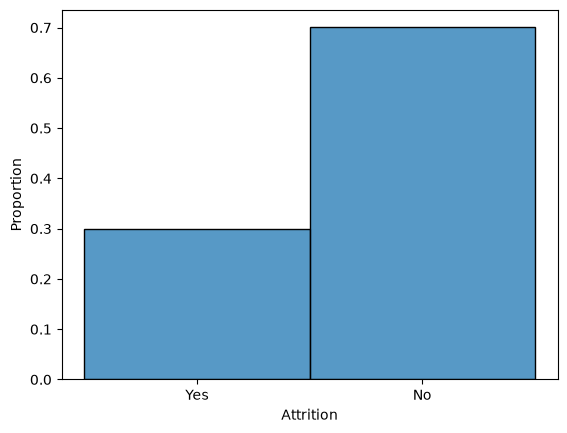

In [23]:
df03['Attrition'].value_counts(normalize=True)
sns.histplot(data=df03, x='Attrition', stat='proportion')

#### 3.1.2. Numerical Variable

KS Statistic: 0.2492, p-value: 0.0000
Interpretacao: Descriminativo

Overlap Coefficient para Age: 0.7755
Interpretacao: Fraco

AUC Univariado para Age: 0.6348
Interpretacao: Descriminativo

Outliers: 0 (0.00%)


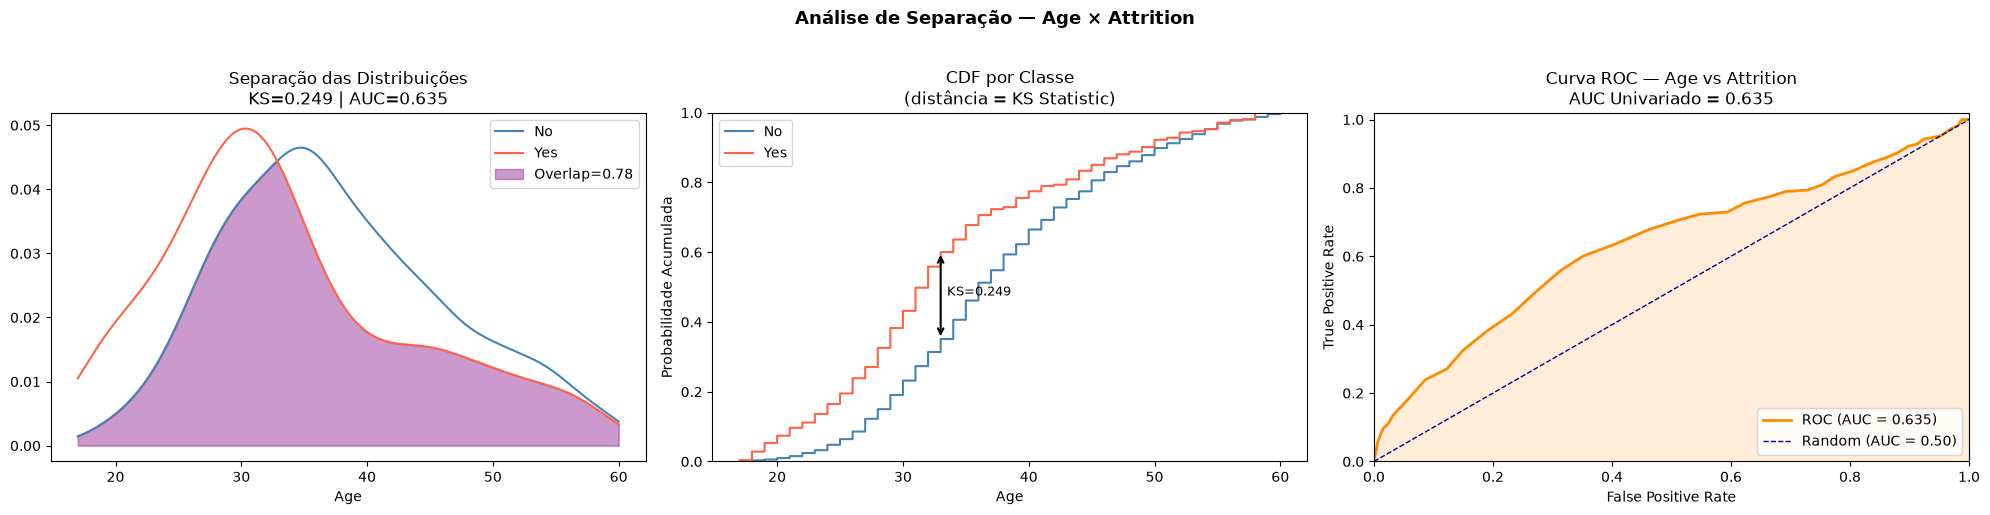

In [43]:
# KS Statistic (Kolmogorov-Smirnov)
age_no = df03.loc[df03['Attrition'] == 'No', 'Age']
age_yes = df03.loc[df03['Attrition'] == 'Yes', 'Age']

ks_stat, ks_p = stats.ks_2samp(age_no, age_yes)

print( f"KS Statistic: {ks_stat:.4f}, p-value: {ks_p:.4f}" )
print( f"Interpretacao: {'Descriminativo' if ks_stat > 0.2 else 'Fraco'}")

#=====================================================================================
# Overlap Coefficient
kde_no = gaussian_kde(age_no)
kde_yes = gaussian_kde(age_yes)

x_range = np.linspace(df_raw['Age'].min(), df_raw['Age'].max(), 1000)
overlap  = np.trapezoid(np.minimum(kde_no(x_range), kde_yes(x_range)), x_range)
print( f"\nOverlap Coefficient para Age: {overlap:.4f}" )
print( f"Interpretacao: {'Descriminativo' if overlap < 0.7 else 'Fraco'}" )

#=====================================================================================
# AUC Univariado
X = df03[['Age']]
y = LabelEncoder().fit_transform( df03['Attrition'] )

model = LogisticRegression()
model.fit( X, y )
y_prob = model.predict_proba( X )[:, 1]

auc = roc_auc_score( y, y_prob )
print( f"\nAUC Univariado para Age: {auc:.4f}" )
print( f"Interpretacao: {'Descriminativo' if auc > 0.55 else 'Fraco'}" )

# --- 3. Outliers (IQR method) ---
series = df03['Age'].dropna()

Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
IQR     = Q3 - Q1
n_outliers = int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())
pct_outliers = n_outliers / len(series) * 100

print(f"\nOutliers: {n_outliers} ({pct_outliers:.2f}%)")

# ================================================
# Plot 1 — KDE com área de overlap destacada
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x_range      = np.linspace(df_raw['Age'].min(), df_raw['Age'].max(), 1000)
kde_no_vals  = kde_no(x_range)
kde_yes_vals = kde_yes(x_range)

axes[0].plot(x_range, kde_no_vals,  label='No',  color='steelblue')
axes[0].plot(x_range, kde_yes_vals, label='Yes', color='tomato')
axes[0].fill_between(x_range, np.minimum(kde_no_vals, kde_yes_vals),
                     alpha=0.4, color='purple', label=f'Overlap={overlap:.2f}')
axes[0].set_title(f'Separação das Distribuições\nKS={ks_stat:.3f} | AUC={auc:.3f}')
axes[0].set_xlabel('Age')
axes[0].legend()

# ================================================
# Plot 2 — CDF por classe (KS Statistic)
# ================================================
axes[1].ecdf(age_no,  label='No',  color='steelblue')
axes[1].ecdf(age_yes, label='Yes', color='tomato')

# Marca o ponto de máxima distância (KS)
all_ages   = np.sort(np.concatenate([age_no, age_yes]))
cdf_no     = np.searchsorted(np.sort(age_no),  all_ages, side='right') / len(age_no)
cdf_yes    = np.searchsorted(np.sort(age_yes), all_ages, side='right') / len(age_yes)
ks_idx     = np.argmax(np.abs(cdf_no - cdf_yes))
ks_x       = all_ages[ks_idx]

axes[1].annotate('', 
    xy=(ks_x, cdf_yes[ks_idx]), xytext=(ks_x, cdf_no[ks_idx]),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
axes[1].text(ks_x + 0.5, (cdf_no[ks_idx] + cdf_yes[ks_idx]) / 2,
             f'KS={ks_stat:.3f}', fontsize=9, color='black')

axes[1].set_title('CDF por Classe\n(distância = KS Statistic)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Probabilidade Acumulada')
axes[1].legend()

# ================================================
# Plot 3 — Curva ROC (AUC Univariado)
# ================================================
fpr, tpr, _ = roc_curve(y, y_prob)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (AUC = 0.50)')
axes[2].fill_between(fpr, tpr, alpha=0.15, color='darkorange')

axes[2].set_title(f'Curva ROC — Age vs Attrition\nAUC Univariado = {auc:.3f}')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.suptitle('Análise de Separação — Age × Attrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



#### 3.1.3. Categorical Variable

### 3.2. Bivatiate Analysis

### 3.3. Multivariate Analysis